# What people like in a used car?

Let's create a model that will be used by used-car-dealerships to understand which inventory sells better  

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices. 

The task at hand is to create a model using existing used-car-sales data to understand the vehicle features (like make, model, mileage, condition, etc.) that influence a customer to buy a used car. 

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import seaborn as sns


In [105]:
vehicles = pd.read_csv("./data/vehicles.csv")

### Data Understanding

In this task, we want to understand the dataset and clean it up to create a better predictive model. Some of the research could be

- Are there some columns that do not make sense?
- Are there rows that do not make sense?
- Are there non-numeric columns that need to be dropped?
- Are there non-numeric columns that are important & need to be converted to numeric?

Below are some prints to understand the data. These are uncommented as needed

In [106]:

# vehicles.head()
# vehicles.describe()

# num of rows and columns
print('Shape: ', vehicles.shape)
# num_cols = 18 num_rows = 426880

# Show me all columns in the dataset
print('Columns: ', vehicles.columns.tolist())

years = np.sort(vehicles["year"].dropna().unique())
print('Years: ', years.tolist())
# 1900 to 2022

print('\nmanufacturer: ', vehicles['manufacturer'].unique().tolist())

print('\ncondition: ', vehicles['condition'].unique().tolist())
# [nan, 'good', 'excellent', 'fair', 'like new', 'new', 'salvage']

print('\ncylinders: ', vehicles['cylinders'].unique().tolist())

print('\nfuel: ', vehicles['fuel'].unique().tolist())

print('\ntitle_status: ', vehicles['title_status'].unique().tolist())

print('\ntransmission: ', vehicles['transmission'].unique().tolist())

print('\ndrive: ', vehicles['drive'].unique().tolist())

print('\nsize: ', vehicles['size'].unique().tolist())

print('\ntype: ', vehicles['type'].unique().tolist())

print('\npaint_color: ', vehicles['paint_color'].unique().tolist())

print('\nstate: ', vehicles['state'].unique().tolist())


Shape:  (426880, 18)
Columns:  ['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'state']
Years:  [1900.0, 1901.0, 1902.0, 1903.0, 1905.0, 1909.0, 1910.0, 1913.0, 1915.0, 1916.0, 1918.0, 1920.0, 1921.0, 1922.0, 1923.0, 1924.0, 1925.0, 1926.0, 1927.0, 1928.0, 1929.0, 1930.0, 1931.0, 1932.0, 1933.0, 1934.0, 1935.0, 1936.0, 1937.0, 1938.0, 1939.0, 1940.0, 1941.0, 1942.0, 1943.0, 1944.0, 1945.0, 1946.0, 1947.0, 1948.0, 1949.0, 1950.0, 1951.0, 1952.0, 1953.0, 1954.0, 1955.0, 1956.0, 1957.0, 1958.0, 1959.0, 1960.0, 1961.0, 1962.0, 1963.0, 1964.0, 1965.0, 1966.0, 1967.0, 1968.0, 1969.0, 1970.0, 1971.0, 1972.0, 1973.0, 1974.0, 1975.0, 1976.0, 1977.0, 1978.0, 1979.0, 1980.0, 1981.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0, 1989.0, 1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0, 1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0,

In [107]:
# Show me all non-null values of year column & sort them
# np.sort(vehicles["year"].dropna().unique())

# Show unique values of given column + number of rows with each of these unique values
vehicles["region"].value_counts()
# vehicles["transmission"].dropna().unique()
# print( len(vehicles["transmission"].dropna().unique()) )


region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
                           ... 
meridian                     28
southwest MS                 14
kansas city                  11
fort smith, AR                9
west virginia (old)           8
Name: count, Length: 404, dtype: int64

In [108]:
# Count the nulls & nans in each column
vehicles.isnull().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

### Data Preparation

From the above prints, we can see that
- Columns id, region, model, VIN, paint_color can be dropped. These don't bring much value to the analysis
- Column 'size' has 300K nulls, it can be dropped
- There are about 174K nulls in 'condition' column. But we cannot fill these with default. This is too important a information to ignore
- Same for 'odometer' & 'title_status' - too important to ignore. We will remove null rows of title_status

In [109]:
print('Shape before dropping: ', vehicles.shape)

# Drop columns id, region, model, VIN, paint_color, state, size, cylinders 
vehicles.drop(columns=['id', 'region', 'model', 'VIN', 'paint_color', 'state', 'size', 'cylinders'], inplace=True)

# Drop all rows with nulls in price, year, manufacturer, condition, cylinders, fuel, odometer, title_status, transmission, drive, type
# vehicles.dropna(subset=['price', 'year', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type'], inplace=True)

# num of rows and columns after dropping
print('Shape after dropping: ', vehicles.shape)


Shape before dropping:  (426880, 18)
Shape after dropping:  (426880, 10)


In [110]:
# Let's make some of the rows with nulls to have some sensible values
print('Nulls before filling: ', vehicles.isnull().sum())

# replace nulls with some sensible values (to keep as many rows as possible)
vehicles = vehicles.fillna({
    'manufacturer': 'unknown',
    'year': 1995,
    'fuel': 'other',
    'transmission': 'other',
    'drive': 'fwd',
    'type': 'other'
})

print('Nulls after filling: ', vehicles.isnull().sum())

Nulls before filling:  price                0
year              1205
manufacturer     17646
condition       174104
fuel              3013
odometer          4400
title_status      8242
transmission      2556
drive           130567
type             92858
dtype: int64
Nulls after filling:  price                0
year                 0
manufacturer         0
condition       174104
fuel                 0
odometer          4400
title_status      8242
transmission         0
drive                0
type                 0
dtype: int64


In [111]:
# Convert year column from float to int
vehicles['year'] = vehicles['year'].astype(int)

In [112]:
# Remove null rows from vehicles dataframe
vehicles = vehicles.dropna()

# Find num of vehicles manufactoured in year 1999 & below
print('Num of rows with year < 2000: ', len(vehicles[vehicles['year'] < 2000]))

# Remove all rows with year < 2000
vehicles = vehicles[vehicles['year'] >= 2000]

# Remove all rows with price <= 25 and > 350000
vehicles = vehicles[(vehicles['price'] > 25) & (vehicles['price'] <= 100000)]

# ignore mileage less than 500 and more than 250000
vehicles = vehicles[(vehicles['odometer'] >= 500) & (vehicles['odometer'] <= 250000)]



Num of rows with year < 2000:  18169


In [113]:

print('Shape after data cleanup: ', vehicles.shape)
print('Nulls after data cleanup:\n', vehicles.isnull().sum())


Shape after data cleanup:  (210371, 10)
Nulls after data cleanup:
 price           0
year            0
manufacturer    0
condition       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
dtype: int64


### Modeling




#### Model Building 

In the following cells, we follow a structured approach to building predictive models:

**1. Exploratory Visualizations**
- Create histograms and distribution plots to understand price patterns
- Analyze vehicle counts by manufacturer, condition, and mileage
- Identify relationships between features and target price

**2. Feature Engineering & Preprocessing**
- Separate categorical columns into ordinal (condition) and nominal (manufacturer, fuel, etc.) types
- Apply StandardScaler to numeric features (year, odometer)
- Use OrdinalEncoder for ordered categories
- Use OneHotEncoder for nominal categories (avoids artificial ordering bias)
- Combine all transformations in a ColumnTransformer pipeline

**3. Model Selection & Hyperparameter Tuning**
- Build two regression models: **Ridge** (L2 regularization) and **Lasso** (L1 regularization)
- Use **RidgeCV** - automatically optimizes alpha across 5-fold cross-validation
- Use **LassoCV** - automatically optimizes alpha across 5-fold cross-validation (built-in feature selection)
- Both models test multiple alpha values efficiently without manual GridSearchCV

**4. Model Evaluation & Comparison**
- Make predictions on test data and calculate metrics for each model
- Calculate RMSE: Root Mean Squared Error (in dollars, penalizes larger errors)
- Calculate R²: Proportion of variance explained by the model
- Compare feature importance: Which features increase/decrease car prices the most
- Ridge keeps all features with scaled coefficients; Lasso performs feature selection (zeros out less important features)

**Why these metrics?**
- **RMSE**: Directly interpretable in dollars; key for business decisions ("model is off by $X on average")
- **R²**: Shows model quality (0-1 scale); indicates how much price variation we capture
- **Feature coefficients**: Identifies which attributes most influence used car prices

count    210371.000000
mean      18951.566937
std       13192.300508
min          27.000000
25%        7900.000000
50%       16300.000000
75%       27990.000000
max      100000.000000
Name: price, dtype: float64


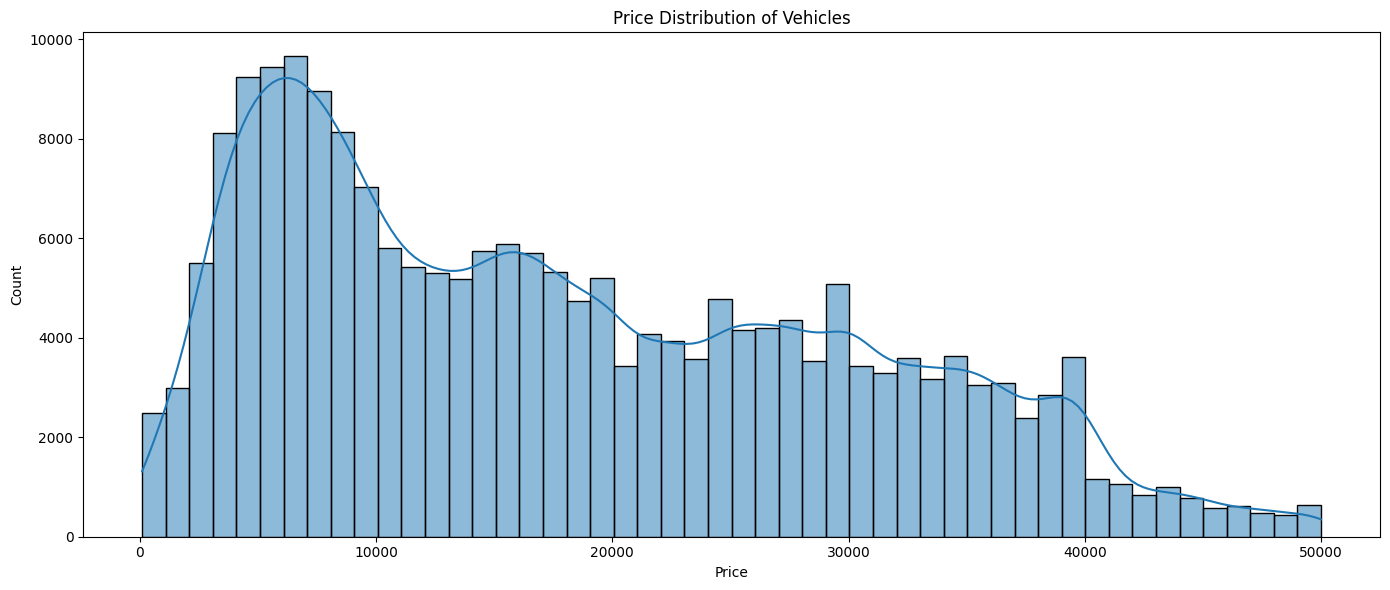

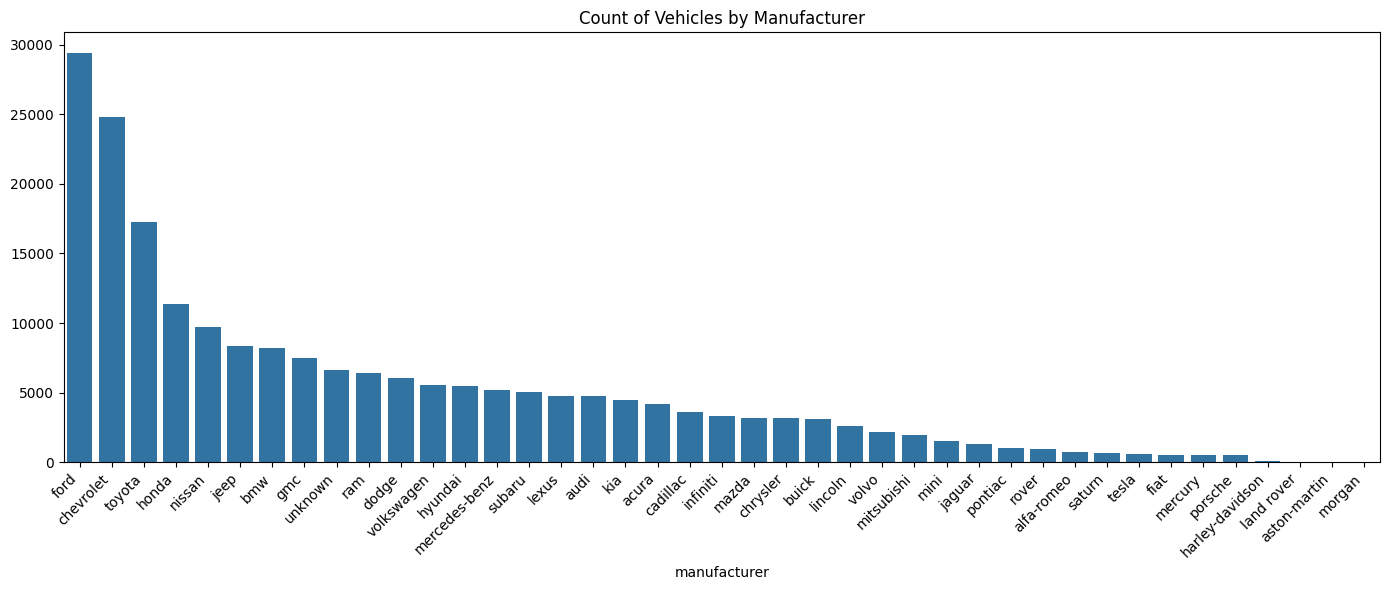

<Figure size 1400x600 with 0 Axes>

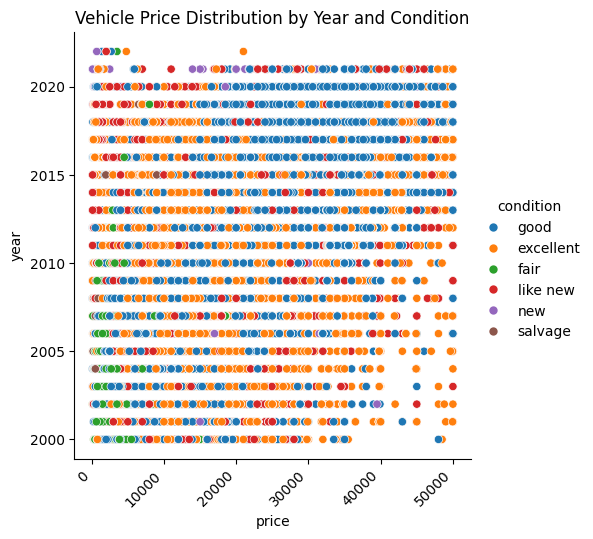

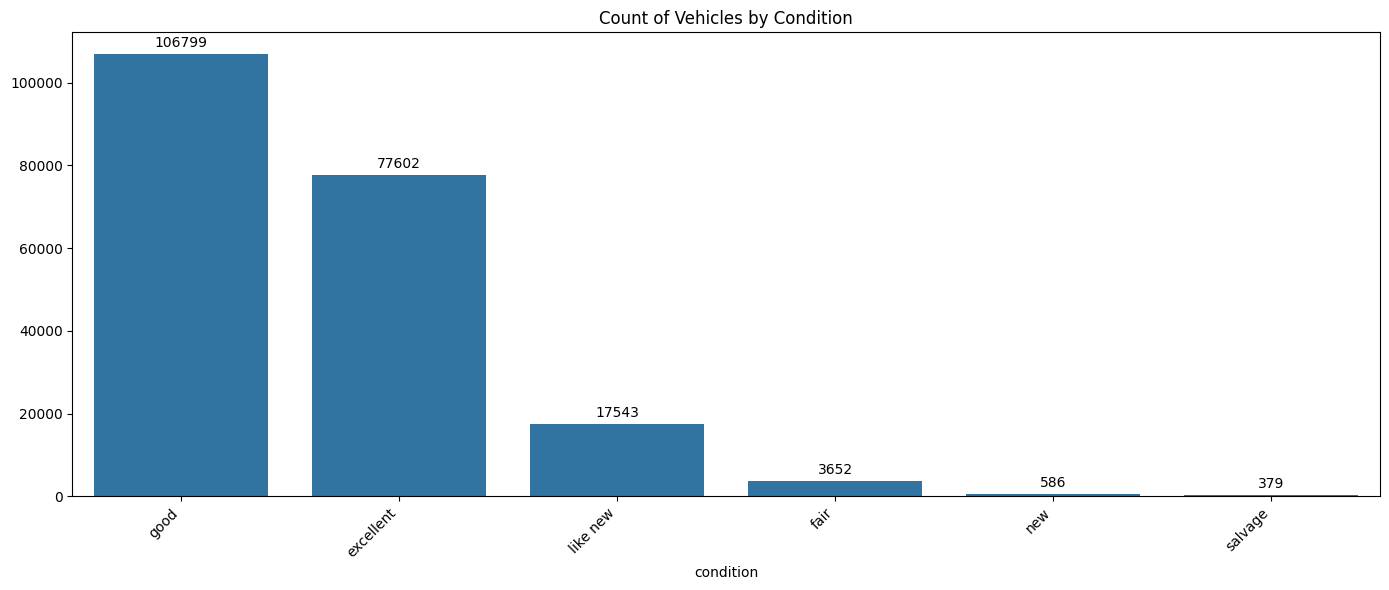

In [114]:
# Let's see some plots

# Check basic statistics
print(vehicles['price'].describe())

# Create a data frame with price between 0 and 50000
no_outliers = vehicles[(vehicles['price'] > 100) & (vehicles['price'] <= 50000)]

# Plot the price histogram of vehicles data
plt.figure(figsize=(14, 6))
sns.histplot(no_outliers['price'], bins=50, kde=True)
plt.title('Price Distribution of Vehicles')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


# Find the number of vehicles by manufacturer
count_by_manufacturer = no_outliers['manufacturer'].value_counts()
# print('Count by manufacturer:\n', count_by_manufacturer)

# Bar plot of count of vehicles by manufacturer
plt.figure(figsize=(14, 6))
sns.barplot(x=count_by_manufacturer.index, y=count_by_manufacturer.values)
plt.xticks(rotation=45, ha='right')
plt.title('Count of Vehicles by Manufacturer')
plt.tight_layout()
plt.show()


# Create a rel plot with price on y-axis, manufacturer on x-axis, and color by condition
plt.figure(figsize=(14, 6))
sns.relplot(data=no_outliers, x='price', y='year', hue='condition', kind='scatter')
plt.xticks(rotation=45, ha='right')
plt.title('Vehicle Price Distribution by Year and Condition')
# plt.tight_layout()
plt.show()

# Find the number of vehicles by condition
count_by_condition = no_outliers['condition'].value_counts()
# Bar plot of count of vehicles by condition
plt.figure(figsize=(14, 6))
sns.barplot(x=count_by_condition.index, y=count_by_condition.values)
plt.xticks(rotation=45, ha='right')
plt.title('Count of Vehicles by Condition')
plt.tight_layout()
# add the count at the top of each bar
for i, v in enumerate(count_by_condition.values):
    plt.text(i, v + 1000, str(v), ha='center', va='bottom')
plt.show()


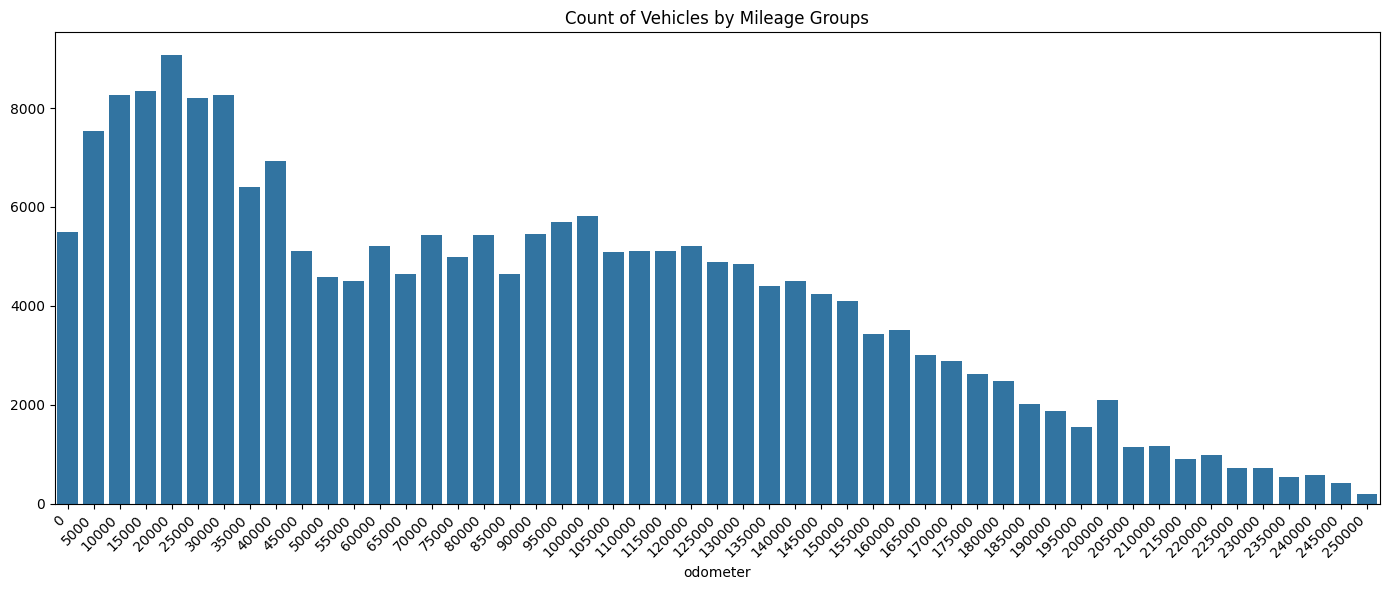

In [115]:
# Create groups of odometer values with 5000 intervals
mileage = (vehicles['odometer'] // 5000) * 5000

# Also remove decimal
mileage = mileage.astype(int)

mileage_counts = mileage.value_counts().sort_index()

# ignore 

# Bar plot of count of vehicles by mileage groups
plt.figure(figsize=(14, 6))
sns.barplot(x=mileage_counts.index, y=mileage_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Count of Vehicles by Mileage Groups')
plt.tight_layout()
#plt.show()

In [116]:
X = no_outliers.drop(columns=['price'])
y = no_outliers['price']

# Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(f"Training features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")

# Column groups
# year              1205
# manufacturer     17646
# condition       174104
# fuel              3013
# odometer          4400
# title_status      8242
# transmission      2556
# drive           130567
# type             92858
num_cols = ['year', 'odometer']
ord_cols = ['condition']
ohe_cols = ['manufacturer', 'fuel', 'title_status', 'transmission', 'drive', 'type']

# 2. Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', OrdinalEncoder(), ord_cols),
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ohe_cols)
    ])

# Pipelines
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RidgeCV(cv=5))
])

lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LassoCV(cv=5, max_iter=10000)) # Increased max_iter for convergence
])

# Fit Models
ridge_pipeline.fit(X_train, y_train)
lasso_pipeline.fit(X_train, y_train)

# Evaluate Performance (Errors)
def evaluate(model, name):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"--- {name} Results ---")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2 Score: {r2:.4f}\n")
    return preds

evaluate(ridge_pipeline, "RidgeCV")
evaluate(lasso_pipeline, "LassoCV")

# Compare Selected Features
feature_names = ridge_pipeline.named_steps['preprocessor'].get_feature_names_out()

# To compare coefficients
importance_df = pd.DataFrame({
    'feature': feature_names,
    'ridge_coef': ridge_pipeline.named_steps['model'].coef_,
    'lasso_coef': lasso_pipeline.named_steps['model'].coef_
})

# Ridge kept features
ridge_selected = importance_df[importance_df['ridge_coef'] != 0]
# Lasso feature selection
lasso_selected = importance_df[importance_df['lasso_coef'] != 0]

print(f"Ridge selected {len(ridge_selected)} features")
print(f"Lasso selected {len(lasso_selected)} features")

# To see what adds the most vs. subtracts the most value:
positive_impact = lasso_selected.sort_values(by='lasso_coef', ascending=False)
print(f'{"-" * 80}')
print('Positively imapacting features:')
print(f'{"-" * 80}')
print(positive_impact.head(10)) # Most expensive features

negative_impact = lasso_selected.sort_values(by='lasso_coef', ascending=True)
print(f'{"-" * 80}')
print('Negatively impacting features:')
print(f'{"-" * 80}')
print(negative_impact.head(10)) # Features that drop the price most

Training features shape: (165248, 9)
Training target shape: (165248,)
--- RidgeCV Results ---
RMSE: 6,107.40
R2 Score: 0.7395

--- LassoCV Results ---
RMSE: 6,137.66
R2 Score: 0.7369

Ridge selected 73 features
Lasso selected 53 features
--------------------------------------------------------------------------------
Positively imapacting features:
--------------------------------------------------------------------------------
                            feature    ridge_coef   lasso_coef
43                 ohe__fuel_diesel   8172.092776  9433.791419
38          ohe__manufacturer_tesla  11501.907299  6987.037045
33        ohe__manufacturer_porsche   9210.918496  6612.730227
0                         num__year   4968.160604  4951.446905
70                  ohe__type_truck   5288.203137  4888.692116
24          ohe__manufacturer_lexus   4167.421294  4333.213233
6            ohe__manufacturer_audi   3454.529860  3688.068258
48          ohe__title_status_clean   3599.171554  3597.329241
2

<Figure size 1400x600 with 0 Axes>

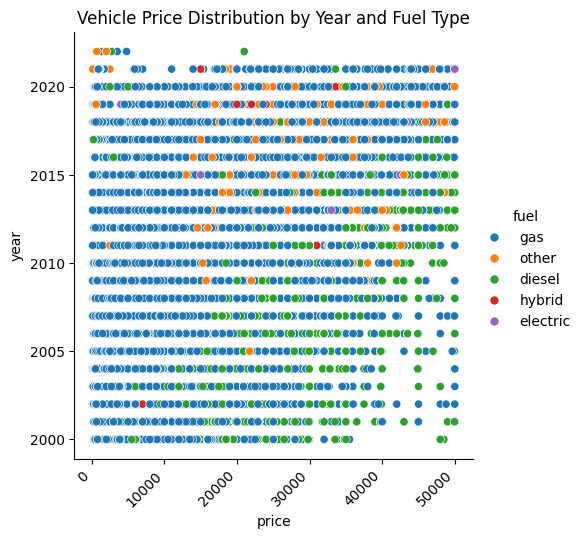

In [124]:
# Create a rel plot with price on x-axis, year on y-axis, and color by fuel-type
plt.figure(figsize=(14, 6))
sns.relplot(data=no_outliers, x='price', y='year', hue='fuel', kind='scatter')
plt.xticks(rotation=45, ha='right')
plt.title('Vehicle Price Distribution by Year and Fuel Type')
# plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Tesla Price Distribution by Year')

<Figure size 1400x600 with 0 Axes>

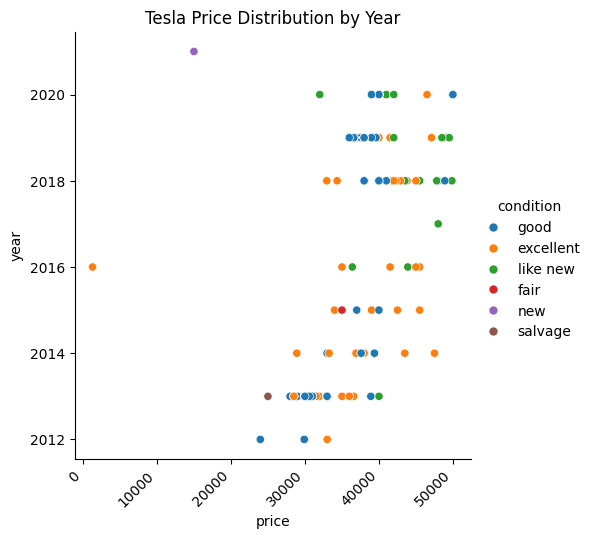

In [120]:
# Create a rel plot with year on y-axis, price on x-axis, only for manufacturer = 'tesla'
plt.figure(figsize=(14, 6))
sns.relplot(data=no_outliers[no_outliers['manufacturer'] == 'tesla'], x='price', y='year',
            hue='condition', kind='scatter')
plt.xticks(rotation=45, ha='right')
plt.title('Tesla Price Distribution by Year')

Text(0.5, 1.0, 'Mitsubishi Price Distribution by Year')

<Figure size 1400x600 with 0 Axes>

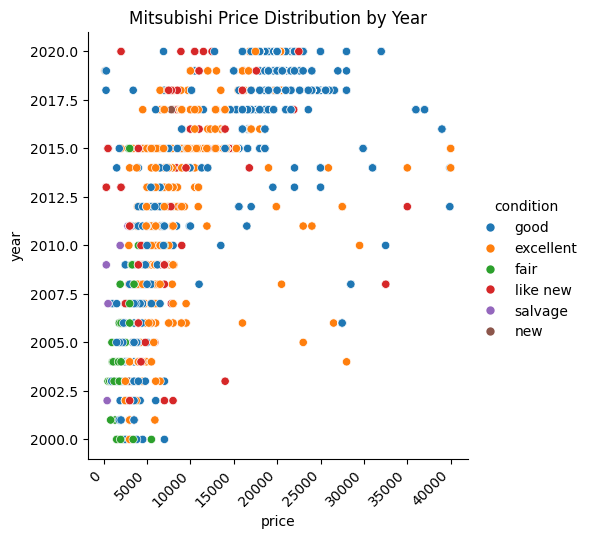

In [121]:
plt.figure(figsize=(14, 6))
sns.relplot(data=no_outliers[no_outliers['manufacturer'] == 'mitsubishi'], x='price', y='year',
            hue='condition', kind='scatter')
plt.xticks(rotation=45, ha='right')
plt.title('Mitsubishi Price Distribution by Year')

In [ ]:
std_year = no_outliers['year'].std()
print(f"Standard Deviation of Year: {std_year:.2f} years")

# To find the exact dollar impact per 1 year:
price_per_year = 4962.363127 / std_year
print(f"Each additional year adds approximately ${price_per_year:,.2f} to the car's price.")